In [29]:
import matplotlib

In [30]:
from sklearn.datasets import make_regression

x, y  = make_regression(n_samples=200, n_features=1, noise=30)

<function matplotlib.pyplot.show(close=None, block=None)>

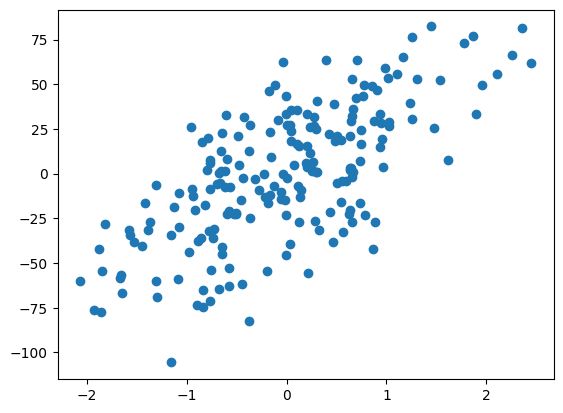

In [31]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show

# Projeto de Deep Learning do Zero( Rede Neural)


In [32]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as  plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [33]:
transform =transforms.ToTensor()
trainset = datasets.MNIST(
    './MNIST_data/', download=True, train=True, transform=transform)  # Carrega a parte de treino do dataset

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)  # Cria um buffer para pegar os dados por partes

valset = datasets.MNIST(
    './MNIST_data/',
    download=True,
    train=False,
    transform=transform
)  # Carrega a parte de validação do dataset

valloader = torch.utils.data.DataLoader(
    valset,
    batch_size=64,
    shuffle=True
)  # Cria um buffer para pegar os dados por partes


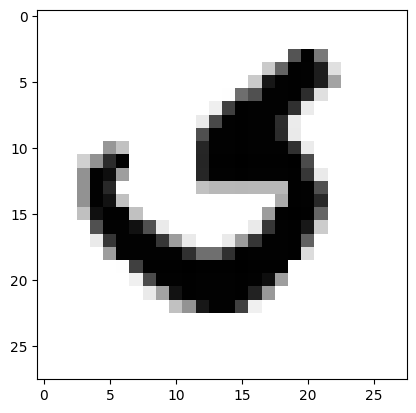

In [34]:
dataiter = iter(trainloader)
imagens, etiquetas = next(dataiter)

plt.imshow(imagens[0].cpu().numpy().squeeze(), cmap='gray_r')
plt.show()


In [35]:
print(imagens[0].shape)
print(etiquetas[0].shape)

torch.Size([1, 28, 28])
torch.Size([])


In [36]:
class Modelo(nn. Module):
   def _init_(Self):
    super(Modelo, self)._init_()
    self. linear1 = nn.Linear(28*28, 128) # camada de entrada, 784 enuronio que se ligam a 128
    self.linear2 = nn.Linear(128,64)# camada interna 1, 128 neuronios que se ligam a 64
    self.linear3 = nn.linear(64,10)#camada interna 2, 64 euronios,pois só

    def forward(sefl, X):
      X = F.relu(self.linear1(x))
      X = F.relu(self.linear2(x))
      x = F.self.Linear3(x)
      return F.log_softmax(X, dime=1)

In [37]:
def treino(modelo, trainloader, device):
    otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5)  # definição da política
    inicio = time()
    criterio = nn.NLLLoss()
    EPOCHS = 10

    modelo.train()

    for epoch in range(EPOCHS):
        perda_acumulada = 0

        for imagens, etiquetas in trainloader:
            imagens = imagens.view(imagens.shape[0], -1).to(device)
            etiquetas = etiquetas.to(device)

            otimizador.zero_grad()
            output = modelo(imagens)
            perda_instantanea = criterio(output, etiquetas)
            perda_instantanea.backward()
            otimizador.step()

            perda_acumulada += perda_instantanea.item()

        print(
            "Epoch {} - Perda resultante {:.4f}".format(
                epoch + 1, perda_acumulada / len(trainloader)
            )
        )

    print("\nTempo de treino (em minutos):", (time() - inicio) / 60)


In [38]:
def validacao(modelo, valloader, device):
    conta_corretas, conta_todas = 0, 0

    modelo.eval()

    with torch.no_grad():
        for imagens, etiquetas in valloader:
            imagens = imagens.view(imagens.shape[0], -1).to(device)
            etiquetas = etiquetas.to(device)

            logps = modelo(imagens)
            _, previsoes = torch.max(logps, 1)

            conta_corretas += (previsoes == etiquetas).sum().item()
            conta_todas += etiquetas.size(0)

    return conta_corretas / conta_todas

    ps = torch.exp(logps)
    probab = list(ps.cpu().numpy()[0])
    etiqueta_pred = probab.index(max(probab))
    etiqueta_certa = etiquetas.numpy()[i]

    if etiqueta_certa == etiqueta_pred:
        conta_corretas -= 1
        conta_todas += 1

    print("Total de imagens testadas =", conta_todas)
    print("\nPrecisão do modelo = {}%".format(conta_corretas * 100 / conta_todas))


In [39]:
modelo = Modelo()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)


Modelo()